In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Grafy losowe (model Erdős-Rényi)

a) Wygeneruj sieć Erdős-Rényi o N = 100 i p = 0.05

In [2]:
G_er = nx.erdos_renyi_graph(n=100, p=0.05, seed=42)

b) Wylistuj wszystkie wierzchołki i krawędzie

In [3]:
print(f"Lb wierzchołków: {G_er.number_of_nodes()}")
print(f"Wierzchołki: {list(G_er.nodes())}")

print(f"\nLb krawędzi: {G_er.number_of_edges()}")
print(f"Krawędzie: {list(G_er.edges())}")

Lb wierzchołków: 100
Wierzchołki: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

Lb krawędzi: 224
Krawędzie: [(0, 2), (0, 10), (0, 13), (0, 20), (0, 42), (0, 68), (0, 90), (1, 3), (1, 27), (1, 29), (2, 75), (2, 96), (3, 7), (3, 34), (3, 52), (3, 78), (4, 9), (4, 30), (4, 42), (4, 96), (5, 14), (5, 22), (5, 25), (5, 39), (5, 49), (5, 64), (6, 17), (6, 26), (6, 65), (7, 20), (7, 52), (7, 64), (8, 62), (8, 71), (8, 96), (9, 19), (9, 37), (9, 63), (10, 22), (10, 32), (10, 61), (10, 79), (10, 92), (10, 99), (11, 12), (11, 27), (12, 16), (12, 24), (12, 30), (12, 56), (12, 59), (12, 65), (12, 75), (12, 76), (12, 84), (14, 42), (14, 93), (14, 99), (15, 27

c) Oblicz stopień (degree) każdego węzła a następnie stwórz histogram
stopni węzłów

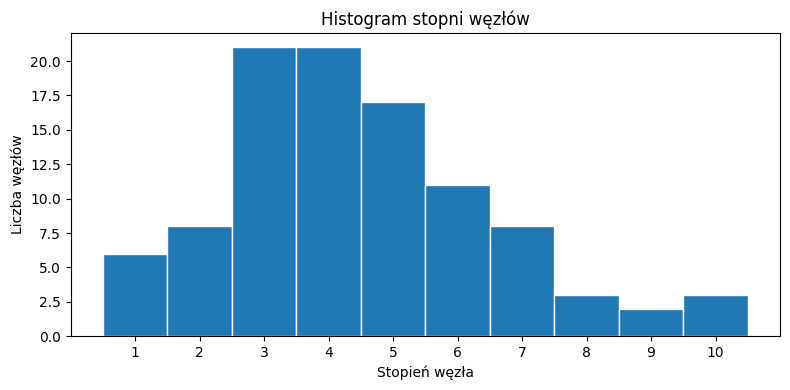

In [4]:
degrees = [deg for node, deg in G_er.degree()]

plt.figure(figsize=(8, 4))
plt.hist(degrees, bins=range(min(degrees), max(degrees)+2), edgecolor='white', align='left')
plt.xticks(range(min(degrees), max(degrees)+1))
plt.xlabel("Stopień węzła")
plt.ylabel("Liczba węzłów")
plt.title("Histogram stopni węzłów")
plt.tight_layout()
plt.show()

#### d) Przygotuj dataframe oraz jego opis statystyczny z wykorzystaniem funkcji describe. 
DataFrame powinien zawierać metryki obliczone dla wygenerowanej sieci losowej, przy czym:
- każdy wiersz odpowiada pojedynczemu wierzchołkowi grafu,
- indeksem ramki danych jest numer wierzchołka grafu

In [5]:
betweenness = nx.betweenness_centrality(G_er)      
closeness = nx.closeness_centrality(G_er)       
clustering = nx.clustering(G_er)                  
pagerank = nx.pagerank(G_er)

if nx.is_connected(G_er):
    avg_path = nx.average_shortest_path_length(G_er)
    diameter = nx.diameter(G_er)
else:
    largest_cc = max(nx.connected_components(G_er), key=len)
    subgraph = G_er.subgraph(largest_cc)
    avg_path = nx.average_shortest_path_length(subgraph)
    diameter = nx.diameter(subgraph)

n_components = nx.number_connected_components(G_er)
density = nx.density(G_er)

In [6]:
df_er = pd.DataFrame({
    'betweenness': betweenness,
    'closeness':   closeness,
    'clustering':  clustering,
    'pagerank':    pagerank,
    'avg_path':    avg_path,      
    'diameter':    diameter,
    'n_components': n_components,
    'density':     density
})

df_er.index.name = 'node'
df_er.describe()

,betweenness,closeness,clustering,pagerank,avg_path,diameter,n_components,density
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.0,100.0,1.000000e+02
mean,0.021936,0.321045,0.042341,0.010000,3.149697e+00,6.0,1.0,4.525253e-02
std,0.021229,0.033182,0.095074,0.003907,1.785306e-15,0.0,0.0,1.394770e-17
min,0.000000,0.228111,0.000000,0.003369,3.149697e+00,6.0,1.0,4.525253e-02
25%,0.007198,0.303681,0.000000,0.007260,3.149697e+00,6.0,1.0,4.525253e-02
50%,0.016789,0.321429,0.000000,0.009203,3.149697e+00,6.0,1.0,4.525253e-02
75%,0.028001,0.342858,0.049603,0.012304,3.149697e+00,6.0,1.0,4.525253e-02
max,0.116356,0.412500,0.666667,0.020749,3.149697e+00,6.0,1.0,4.525253e-02


#### e) ile jest komponentów (connected components) w grafie

In [7]:
components = list(nx.connected_components(G_er))
print(f"Liczba komponentów: {len(components)}")

Liczba komponentów: 1


#### f) zwizualizuj graf w taki sposób, aby rozmiar węzłów odpowiadał mierze PageRank

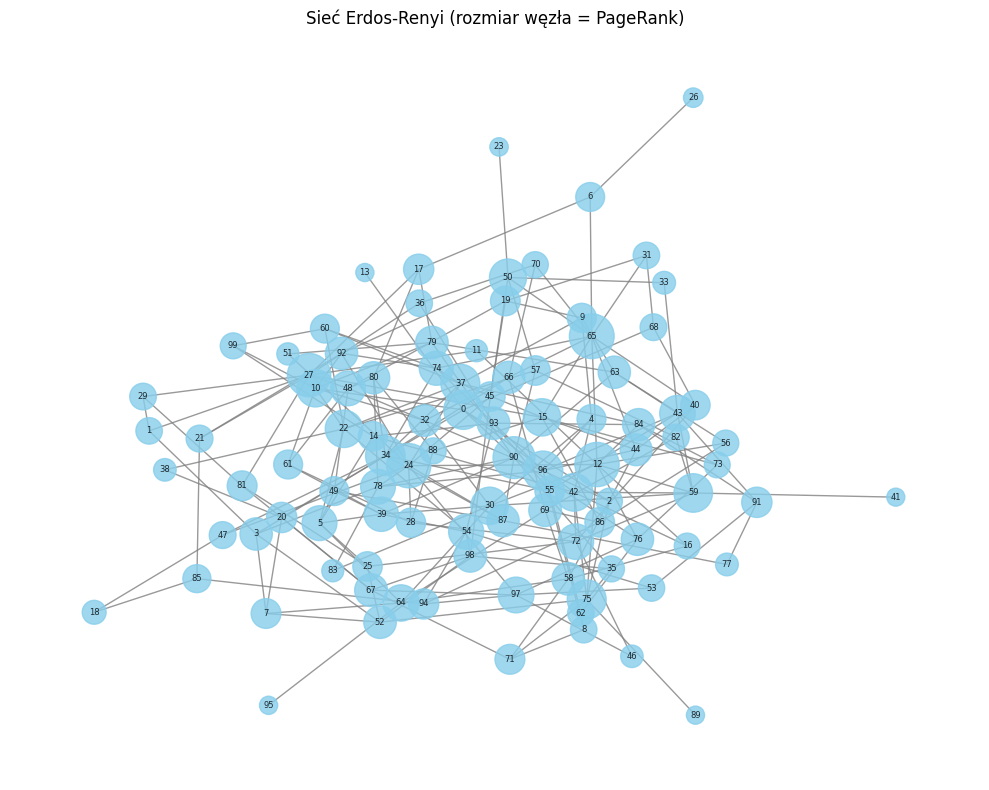

In [8]:
plt.figure(figsize=(10, 8))
node_sizes = [pagerank[node] * 50000 for node in G_er.nodes()]
pos = nx.spring_layout(G_er, seed=42)

nx.draw_networkx(
    G_er, pos,
    node_size=node_sizes,
    node_color='skyblue',
    edge_color='gray',
    alpha=0.8,
    with_labels=True,
    font_size=6
)

plt.title("Sieć Erdos-Renyi (rozmiar węzła = PageRank)")
plt.axis('off')
plt.tight_layout()
plt.show()

## Sieci bezskalowe (model Barabási-Albert)

#### a) Wygeneruj graf wedle modelu Barabási-Albert z N = 1000 i m0 = m = 3

In [9]:
G_ba = nx.barabasi_albert_graph(n=1000, m=3, seed=42)

#### b) Zwizualizuj graf layoutem Kamada-Kawai

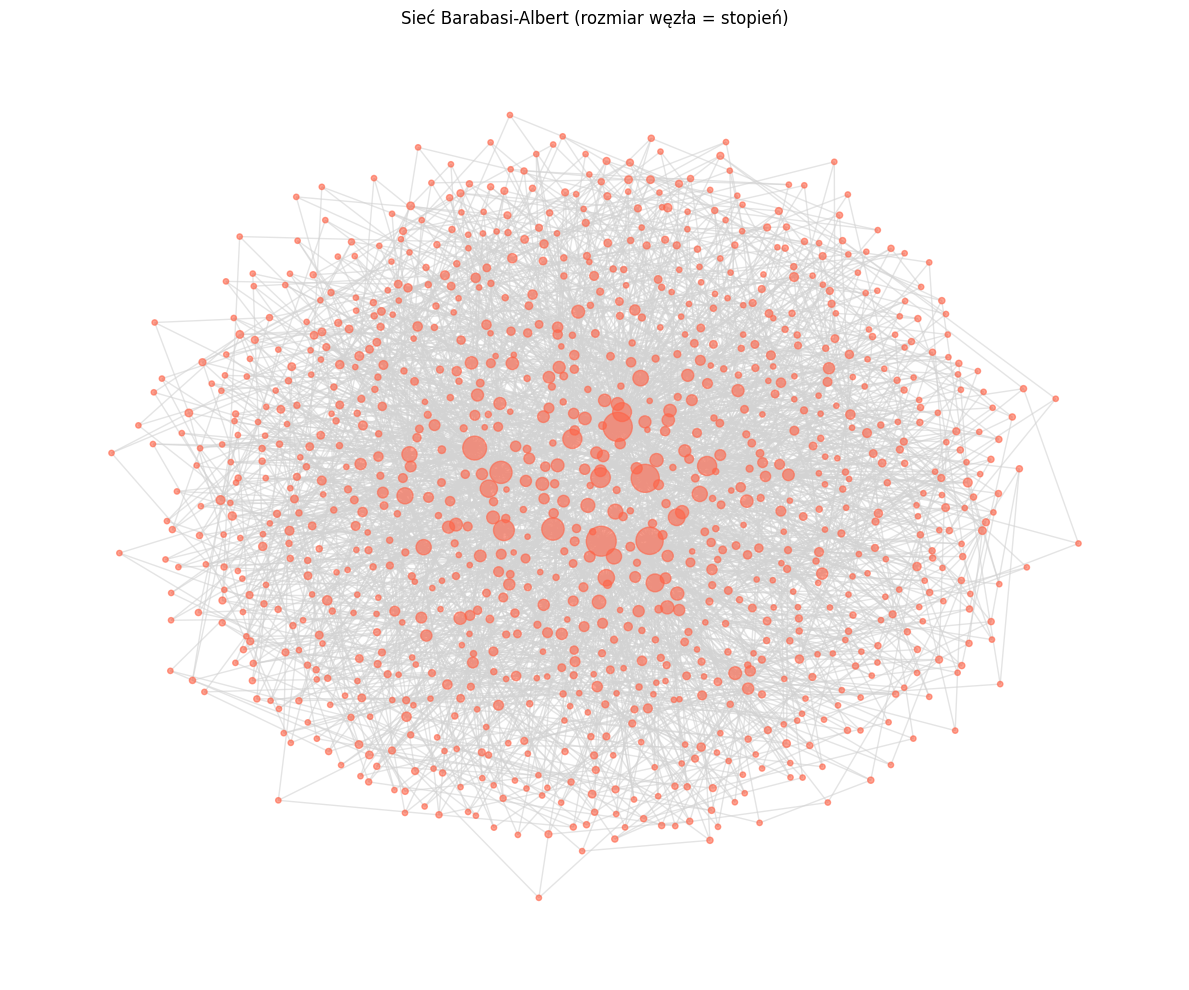

In [10]:
plt.figure(figsize=(12, 10))

pos_ba = nx.kamada_kawai_layout(G_ba)

degrees_ba = dict(G_ba.degree())
node_sizes_ba = [degrees_ba[n] * 5 for n in G_ba.nodes()]

nx.draw_networkx(
    G_ba, pos_ba,
    node_size=node_sizes_ba,
    node_color='tomato',
    edge_color='lightgray',
    alpha=0.6,
    with_labels=False,  
)

plt.title("Sieć Barabasi-Albert (rozmiar węzła = stopień)")
plt.axis('off')
plt.tight_layout()
plt.show()

#### c) Znajdź najbardziej centralny węzeł według miary pośrednictwa (betweenness), jaki ma numer?

In [11]:
betweenness_ba = nx.betweenness_centrality(G_ba)
max_betweenness_node = max(betweenness_ba, key=betweenness_ba.get)
print(f"Numer węzła: {max_betweenness_node} (betweenness={betweenness_ba[max_betweenness_node]:.4f}, degree={degrees_ba[max_betweenness_node]})")

Numer węzła: 4 (betweenness=0.1513, degree=93)


#### d) Jaka jest średnica grafu

In [12]:
largest_cc_ba = max(nx.connected_components(G_ba), key=len)
G_ba_sub = G_ba.subgraph(largest_cc_ba)

diameter_ba = nx.diameter(G_ba_sub)

print(f"Średnica grafu: {diameter_ba}")

Średnica grafu: 6


#### e) Jakie różnice widzisz pomiędzy grafem Barabási-Albert i Erdős-Rényi.

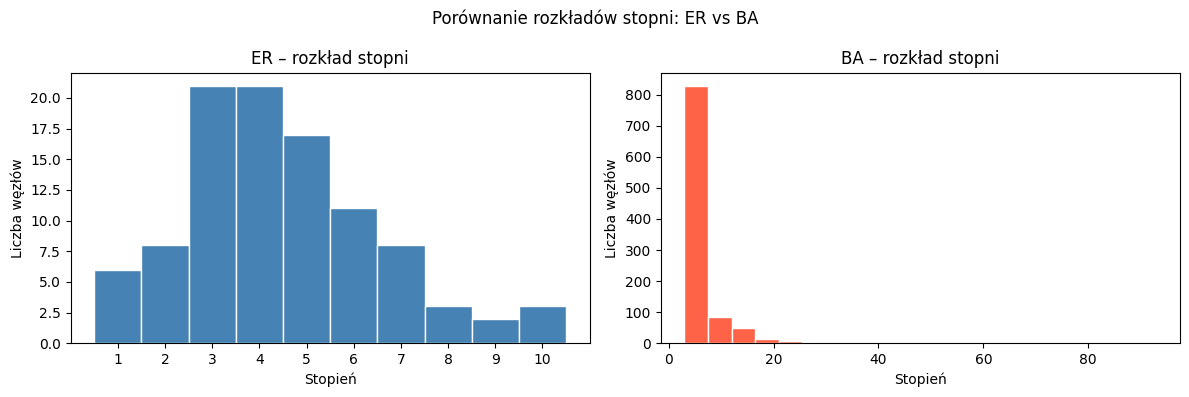

In [13]:
degrees_er = [d for n, d in G_er.degree()]
degrees_ba_all = [d for n, d in G_ba.degree()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(degrees_er, bins=range(min(degrees_er), max(degrees_er)+2), align='left', color='steelblue', edgecolor='white')
axes[0].set_title("ER – rozkład stopni")
axes[0].set_xlabel("Stopień")
axes[0].set_ylabel("Liczba węzłów")
axes[0].set_xticks(range(min(degrees_er), max(degrees_er)+1))

axes[1].hist(degrees_ba_all, bins=20, color='tomato', edgecolor='white')
axes[1].set_title("BA – rozkład stopni")
axes[1].set_xlabel("Stopień")
axes[1].set_ylabel("Liczba węzłów")

plt.suptitle("Porównanie rozkładów stopni: ER vs BA")
plt.tight_layout()
plt.show()


W ER wszystkie wierzchołki mają dosyć podobny stopień wierzchołka. W BA powstają huby — kilka węzłów dominuje nad resztą.